<a href="https://colab.research.google.com/github/AdityaInTech/Task-Modules/blob/main/Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Heart Disease Prediction**

In [ ]:
# Cell 1: Imports for Week 4 Evaluation and Capstone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc

**Practice Questions (Cross-Validation, SVM GridSearch & Joblib)**

In [ ]:
# Cell 2: Practice Questions - SVM Optimization and Model Saving

# 1. Load data and split
print("Loading Medical Data...")
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data (SVMs are very sensitive to unscaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Implement GridSearchCV for SVM
print("\nRunning GridSearchCV for SVM...")
svm_model = SVC(probability=True, random_state=42)
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}
grid_search = GridSearchCV(svm_model, param_grid, cv=3)
grid_search.fit(X_train_scaled, y_train)

best_svm = grid_search.best_estimator_
print(f"Best SVM Parameters found: {grid_search.best_params_}")

# 3. Use cross_val_score to test accuracy
cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5)
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean() * 100:.2f}%")

# 4. Save trained model using joblib
model_filename = 'optimized_svm_model.pkl'
joblib.dump(best_svm, model_filename)
print(f"\nModel successfully saved as '{model_filename}'")

# 5. Load model and predict on new data
loaded_svm = joblib.load(model_filename)
new_patient_data = [X_test_scaled[0]] # Grabbing the first row of test data as a "new" patient
prediction = loaded_svm.predict(new_patient_data)
print(f"Prediction for new patient (0=Malignant, 1=Benign): {prediction[0]}")

Loading Medical Data...

Running GridSearchCV for SVM...
Best SVM Parameters found: {'C': 1, 'kernel': 'rbf'}
Cross-Validation Accuracy Scores: [0.97802198 0.96703297 0.98901099 0.98901099 0.95604396]
Average CV Accuracy: 97.58%

Model successfully saved as 'optimized_svm_model.pkl'
Prediction for new patient (0=Malignant, 1=Benign): 1


**Capstone Project**

--- Starting Capstone Evaluation Pipeline ---

Model Accuracy:  97.37%
Model Precision: 97.22%
Model Recall:    98.59%


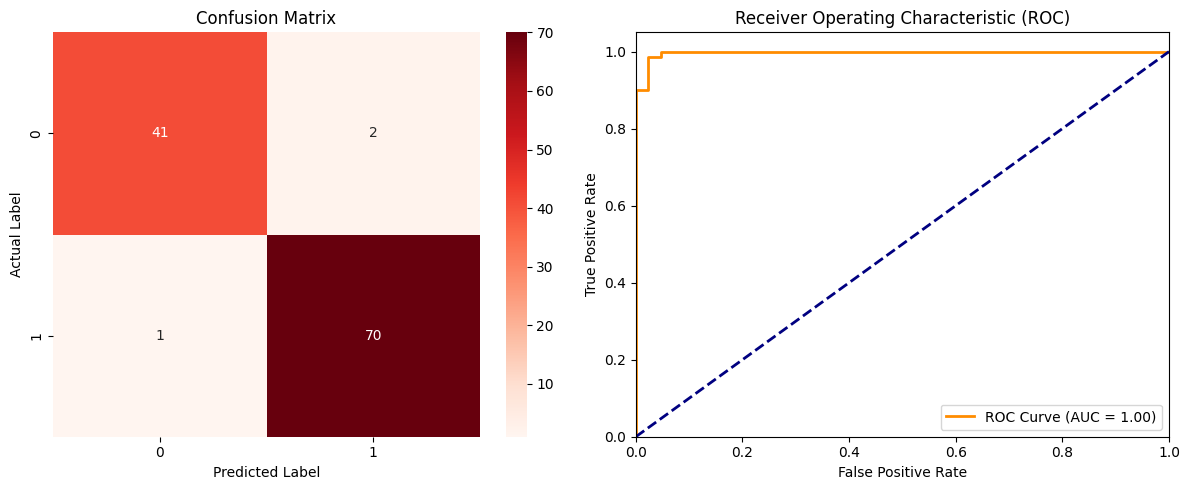

In [ ]:
# Cell 3: Capstone Project Pipeline - Medical Disease Prediction

print("--- Starting Capstone Evaluation Pipeline ---\n")

# 1. Train Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. Evaluate accuracy, precision, recall
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1] # Probabilities needed for ROC curve

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Model Accuracy:  {accuracy * 100:.2f}%")
print(f"Model Precision: {precision * 100:.2f}%")
print(f"Model Recall:    {recall * 100:.2f}%")

# 3. Confusion matrix visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# 4. ROC curve visualization
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

--- Starting Capstone Option 1 Pipeline ---

Dataset successfully loaded. First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



--- Evaluation Metrics ---
Model Accuracy:  85.25%
Model Precision: 87.10%
Model Recall:    84.38%



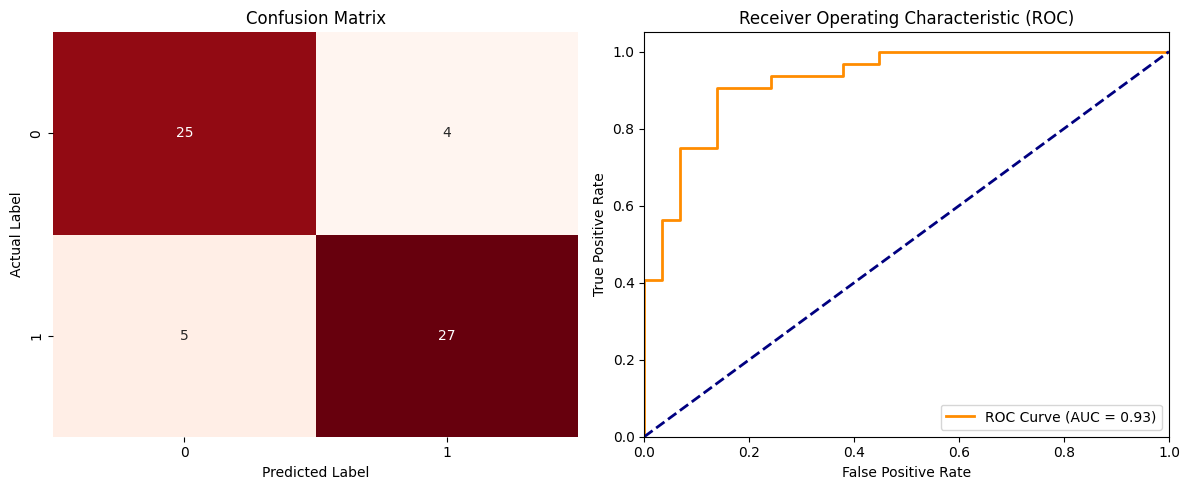

In [ ]:
# Capstone Project: Heart Disease Prediction (Full Pipeline)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

print("--- Starting Capstone Option 1 Pipeline ---\n")

# 1. Load Dataset directly from a working Raw GitHub URL
url = 'https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv'
heart_df = pd.read_csv(url)
print("Dataset successfully loaded. First 5 rows:")
display(heart_df.head())

# 2. Data Cleaning & Preprocessing
# Check for and drop any missing values
heart_df = heart_df.dropna()

# One-hot encode categorical features if present
heart_df = pd.get_dummies(heart_df, drop_first=True)

# Separate features (X) and target (y)
# The target column in this dataset is named 'target'
X = heart_df.drop('target', axis=1)
y = heart_df['target']

# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression Model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 5. Evaluate Accuracy, Precision, and Recall
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n--- Evaluation Metrics ---")
print(f"Model Accuracy:  {accuracy * 100:.2f}%")
print(f"Model Precision: {precision * 100:.2f}%")
print(f"Model Recall:    {recall * 100:.2f}%\n")

# 6. Confusion Matrix & ROC Curve Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Confusion Matrix
plt.subplot(1, 2, 1)
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Plot 2: ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()